In [75]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import mixture
import seaborn as sns

In [76]:
np.random.seed(33) #como?

In [77]:
orig_mixture = mixture.GaussianMixture(
    n_components=2,
    covariance_type="spherical",
    weights_init=np.array([0.4, 0.6]),
    means_init=np.array([[-6], [2]]),
    precisions_init = np.array([0.25, 0.25]),
    random_state=33
)

In [78]:
orig_mixture.covariances_ = np.array([4,4])
orig_mixture.weights_ = np.array([0.4, 0.6])
orig_mixture.means_ = np.array([[-6], [2]])
orig_mixture.precisions_ =  np.array([0.25, 0.25])
orig_mixture.fit_ = True

In [79]:
estim_mixture = mixture.GaussianMixture(
    n_components=3,
    covariance_type="spherical",
    weights_init=np.array([0.7, 0.1, 0.2]),
    means_init=np.array([[-6], [2], [0]]),
    precisions_init=np.array([0.25, 0.25, 0.25]),
    random_state=33
)

In [88]:
def estimate_mixture(samples, gamma, max_iter):
    estim_mixture.covariances_ = np.array([4,4,4])
    estim_mixture.weights_ = np.array([0.7, 0.1, 0.2])
    estim_mixture.means_ = np.array([[-6], [2], [0]])
    estim_mixture.precisions_ =  np.array([0.25, 0.25, 0.25])
    estim_mixture.precisions_cholesky_ = np.array([0.5, 0.5, 0.5])
    estim_mixture.fit_ = True

    avg_log_like_threshold = -10e9

    for iter in range(max_iter):
        ac_probs = estim_mixture.predict_proba(samples)
        nums = [0,0,0]
        ac_pi = [0,0,0]
        for p in ac_probs:
            for n in range(len(nums)):
                nums[n] += p[n] * (1 + gamma * p[n])
                
        for pi in range(len(ac_pi)):
            ac_pi[pi] = nums[pi]/sum(nums)

        estim_mixture.weights_ = ac_pi

        avg_log_like = estim_mixture.score(samples)
        if avg_log_like < avg_log_like_threshold:
            break
        avg_log_like_threshold = avg_log_like
    return (abs(estim_mixture.weights_[0] - 0.4) + abs(estim_mixture.weights_[1] - 0.6) + estim_mixture.weights_[2]), iter


In [81]:
def experiment(gamma, fig_name = 'res'):
    sampling={50:[], 1000:[]}
    for n in list(sampling.keys()):
        samples, _ = orig_mixture.sample(n)
        estimate_mixture(samples, gamma, 1000)
        sampling[n] = estim_mixture.sample(10000)[0]
    
    true_sample,_ = orig_mixture.sample(10000)
    
    sns.distplot(
        sampling[50],
        rug_kws={"color": "g"},
        hist=False,
        label="50 samples",
        kde_kws={"linestyle": "--"}
    )
    sns.distplot(
        sampling[1000],
        rug_kws={"color": "b"},
        hist=False,
        label="1000 samples",
        kde_kws={"linestyle": ":"},
    )
    sns.distplot(
        true_sample,
        rug_kws={"color": "r"},
        hist=False,
        label="Original mixture",
        kde_kws={"linestyle": "dashdot"},
    )
    plt.legend()
    plt.savefig("{}.png".format(fig_name))

In [102]:
samples, _ = orig_mixture.sample(1000)
score, iters = estimate_mixture(samples, 0.3, 1000)
print(score, iters)

0.006948535712818245 123


13
123


C:\Users\miguel\AppData\Local\Temp\ipykernel_6564\2567142666.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
C:\Users\miguel\AppData\Local\Temp\ipykernel_6564\2567142666.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
C:\Users\miguel\AppData\Local\Temp\ipykernel_656

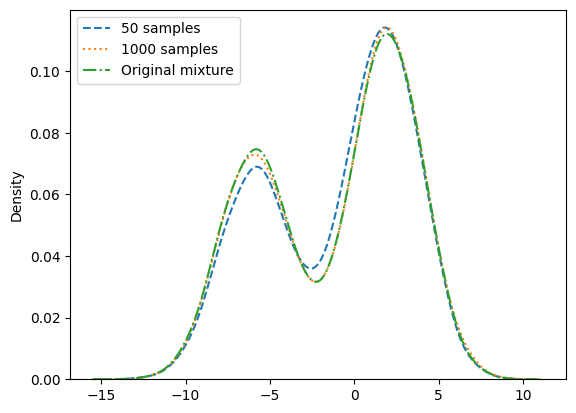

In [87]:
#experiment(0, 'no-reg')
#experiment(0.1, 'reg01')
#experiment(0.2, 'reg02')
experiment(0.3, 'reg03')